# Day 1: Answer Key

Worked solutions for the **"you try"** exercises in the Day 1 morning material (Python basics and simulation foundations), mirroring `Day1_revised.ipynb`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Recreate the Session 2 classroom grade book so this answer key runs on its own.
rng = np.random.default_rng(seed=7)
n_students = 36
class_data = pd.DataFrame({
    "student_id": np.arange(1, n_students + 1),
    "study_minutes": rng.integers(20, 180, size=n_students),
    "absences": rng.integers(0, 6, size=n_students),
    "lab_group": rng.choice(["A", "B", "C"], size=n_students),
})
class_data["quiz_score"] = (
    55
    + 0.18 * class_data["study_minutes"]
    - 2.5 * class_data["absences"]
    + rng.normal(0, 7, size=n_students)
).clip(0, 100).round(1)

## Session 1 · Exercise 1: parameters

**Core:** `initial_infected = 25` gives `initial_susceptible = 500 - 25 = 475`; the three counts still sum to 500.

**Stretch:** e.g. `initial_vaccinated = 50`, then `initial_susceptible = population - initial_infected - initial_vaccinated`.

## Session 1 · Exercise 2: functions

**The blank:** call `rectangle_area` with two numbers, e.g. `rectangle_area(4, 3)`.

**Core:** `celsius_to_fahrenheit(100)` returns `212.0` (the boiling-point check). **Stretch:** `minutes_to_seconds(m)` returns `m * 60`.

In [2]:
def rectangle_area(width, height):
    return width * height

def celsius_to_fahrenheit(celsius):
    return celsius * 9 / 5 + 32

# Core: check a few temperatures
print("0 C  =", celsius_to_fahrenheit(0), "F")
print("37 C =", celsius_to_fahrenheit(37), "F")
print("100 C =", celsius_to_fahrenheit(100), "F")

# The TODO blank:
print("area of 4 x 3 =", rectangle_area(4, 3))

# Stretch:
def minutes_to_seconds(m):
    return m * 60

print("5 minutes =", minutes_to_seconds(5), "seconds")

0 C  = 32.0 F
37 C = 98.6 F
100 C = 212.0 F
area of 4 x 3 = 12
5 minutes = 300 seconds


## Session 1 · Exercise 3: two curves on one axis

**The blank:** `plt.plot(time, recovered, marker="s", label="Recovered")`.

**Stretch:** e.g. `plt.title("Infected and recovered over 10 days")` and `plt.legend()` so both series are labeled.

## Session 1 · Exercise 3b: changing the function

Each number in `f(x) = height * exp(-((x - center)/width)**2)` controls one feature: **center** slides the peak sideways, **width** makes it wider or narrower, **height** scales it up or down.

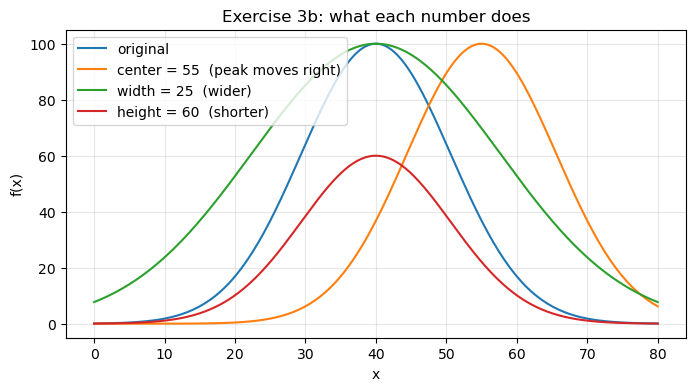

In [3]:
def f_original(x):
    return 100 * np.exp(-((x - 40) / 15) ** 2)   # the original bell-shaped curve

# Redefine f a few times, changing ONE number each time (no keyword arguments needed).
def f_right(x):        # center 40 -> 55 slides the peak to the right
    return 100 * np.exp(-((x - 55) / 15) ** 2)

def f_wider(x):        # width 15 -> 25 makes the hump wider
    return 100 * np.exp(-((x - 40) / 25) ** 2)

def f_shorter(x):      # height 100 -> 60 scales the peak down
    return 60 * np.exp(-((x - 40) / 15) ** 2)

x = np.linspace(0, 80, 200)
plt.figure(figsize=(8, 4))
plt.plot(x, f_original(x), label="original")
plt.plot(x, f_right(x), label="center = 55  (peak moves right)")
plt.plot(x, f_wider(x), label="width = 25  (wider)")
plt.plot(x, f_shorter(x), label="height = 60  (shorter)")
plt.xlabel("x"); plt.ylabel("f(x)"); plt.title("Exercise 3b: what each number does")
plt.legend(); plt.grid(True, alpha=0.3); plt.show()

## Session 1 · Exercise 3c: reading the real curve

**Core:** yes. A 14-day window averages over more days, so the curve is smoother than the 7-day one, though it also flattens the peak slightly and trims a few days off each end of the smoothed series.

**Stretch:** the Arizona curve is a single hump that rises and falls, much like the function in 3b, which is why an SIR model can approximate it. But note it is *skewed* (faster rise, slower decay), not a symmetric bell. Day 2 builds the SIR model that produces this single hump, and on Day 3 the fit to the real Arizona data is where that rise/fall asymmetry becomes visible. For the plot itself, `plt.scatter` is usually easier to read than `plt.plot` for spiky day-to-day counts, since the connecting lines exaggerate the noise.

## Session 1 · Exercise 4: Visualization Choice Board

This exercise is an open-ended choice board, so there is no single answer key: any of the three Core questions is a valid choice, and the participant notebook already ships a starter chart (a scatter of `absences` vs `quiz_score`). One natural chart per Core question:

- **Do fewer absences go with higher scores?** a scatter, `plt.scatter(class_data["absences"], class_data["quiz_score"])` (the starter).
- **Which lab group scores highest?** a grouped bar, `class_data.groupby("lab_group")["quiz_score"].median().plot(kind="bar")`.
- **What does study time look like?** a histogram, `plt.hist(class_data["study_minutes"], bins=10)`.

Any chart that honestly answers the question a teacher picked is correct; the Stretch is to make two charts for the same question and compare which reads more clearly.

## Session 2 · Exercise 5: Count with a Loop and a Condition

The Core answer just runs the seed cell and changes `threshold`. Below is a worked **Stretch** answer: it uses `if / elif / else` with two cutoffs to sort every quiz score into three bands and tallies them, then finds the top score by hand with a loop and checks it against the NumPy one-liner.

In [4]:
def score_band(score):
    """Return 'low', 'mid', or 'high' for a quiz score using two cutoffs.

    Parameters
    ----------
    score : float
        A single quiz score.

    Returns
    -------
    str
        One of 'low', 'mid', or 'high'.
    """
    if score < 70:
        return "low"
    elif score < 85:
        return "mid"
    else:
        return "high"


band_counts = {"low": 0, "mid": 0, "high": 0}
for score in class_data["quiz_score"]:
    band = score_band(score)
    band_counts[band] = band_counts[band] + 1

print("students in each band:", band_counts)
print("total students:", sum(band_counts.values()))

# Find the top score by hand, then check with NumPy.
running_max = class_data["quiz_score"].iloc[0]
for score in class_data["quiz_score"]:
    if score > running_max:
        running_max = score

print("highest quiz score, found by hand:", running_max)
print("numpy check:", class_data["quiz_score"].max())

students in each band: {'low': 19, 'mid': 14, 'high': 3}
total students: 36
highest quiz score, found by hand: 92.7
numpy check: 92.7
